# San Luis Valley aeromagentic levelling

In [1]:
%load_ext autoreload
%autoreload 2


import logging

import cmocean
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import verde as vd

import airbornegeo

# setup logging to get some additional info from the airbornegeo functions
logging.getLogger("airbornegeo").setLevel("INFO")
logging.basicConfig()

/home/mdtanker/airbornegeo/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

In [5]:
data_df = pd.read_csv("data/san_luis_magnetics.csv")

# convert dataframe into geodataframe
data_df = gpd.GeoDataFrame(
    data_df,
    geometry=gpd.points_from_xy(data_df.easting, data_df.northing),
    crs="EPSG:3031",
)

data_df.head()

,line,line_type,lat84,lon84,easting,northing,unixtime,height,unlevelled_tfa,levelled_tfa,geometry
0,1,line,37.5256,-105.6335,443997.28,4153366.29,1.099466e+09,2488.22,-837.13,-841.75,POINT (443997.28 4153366.29)
1,1,line,37.5256,-105.6338,443974.30,4153366.44,1.099466e+09,2488.37,-837.06,-841.68,POINT (443974.3 4153366.44)
2,1,line,37.5256,-105.6341,443951.32,4153365.49,1.099466e+09,2488.51,-837.00,-841.62,POINT (443951.32 4153365.49)
3,1,line,37.5256,-105.6343,443927.47,4153365.65,1.099466e+09,2488.66,-836.92,-841.54,POINT (443927.47 4153365.65)
4,1,line,37.5256,-105.6346,443904.49,4153365.80,1.099466e+09,2488.80,-836.87,-841.49,POINT (443904.49 4153365.8)


In [6]:
data_df.describe()

,line,lat84,lon84,easting,northing,unixtime,height,unlevelled_tfa,levelled_tfa
count,1.271290e+06,1.271290e+06,1.271290e+06,1.271290e+06,1.271290e+06,1.271290e+06,1.271290e+06,1.271290e+06,1.271290e+06
mean,3.201125e+02,3.706693e+01,-1.058167e+02,4.274058e+05,4.102621e+06,1.100047e+09,2.536180e+03,-5.682331e+02,-5.682027e+02
std,1.977824e+02,2.912172e-01,1.592203e-01,1.410116e+04,3.232789e+04,2.658211e+06,1.042036e+02,2.246053e+02,2.223726e+02
min,1.000000e+00,3.644480e+01,-1.061741e+02,3.960613e+05,4.033616e+06,1.039259e+09,2.250880e+03,-2.336730e+03,-2.334330e+03
25%,1.450000e+02,3.684740e+01,-1.059410e+02,4.162816e+05,4.078258e+06,1.099473e+09,2.472980e+03,-7.018800e+02,-7.003200e+02
50%,2.990000e+02,3.710280e+01,-1.058133e+02,4.275882e+05,4.106630e+06,1.099639e+09,2.506760e+03,-5.773700e+02,-5.767200e+02
75%,4.980000e+02,3.731080e+01,-1.056870e+02,4.388134e+05,4.129647e+06,1.100764e+09,2.578120e+03,-4.536800e+02,-4.550900e+02
max,6.500000e+02,3.755870e+01,-1.054484e+02,4.602512e+05,4.157199e+06,1.102070e+09,3.136350e+03,2.083250e+03,1.973760e+03


In [14]:
data_df["distance_along_line"] = airbornegeo.along_track_distance(
    data_df, easting_column="easting", northing_column="northing", groupby_column="line"
)
data_df.head()

,line,line_type,lat84,lon84,easting,northing,unixtime,height,unlevelled_tfa,levelled_tfa,geometry,along_line_distance,distance_along_line
0,1,line,37.5256,-105.6335,443997.28,4153366.29,1.099466e+09,2488.22,-837.13,-841.75,POINT (443997.28 4153366.29),0.000000,0.000000
1,1,line,37.5256,-105.6338,443974.30,4153366.44,1.099466e+09,2488.37,-837.06,-841.68,POINT (443974.3 4153366.44),22.980490,22.980490
2,1,line,37.5256,-105.6341,443951.32,4153365.49,1.099466e+09,2488.51,-837.00,-841.62,POINT (443951.32 4153365.49),45.980118,45.980118
3,1,line,37.5256,-105.6343,443927.47,4153365.65,1.099466e+09,2488.66,-836.92,-841.54,POINT (443927.47 4153365.65),69.830654,69.830654
4,1,line,37.5256,-105.6346,443904.49,4153365.80,1.099466e+09,2488.80,-836.87,-841.49,POINT (443904.49 4153365.8),92.811144,92.811144


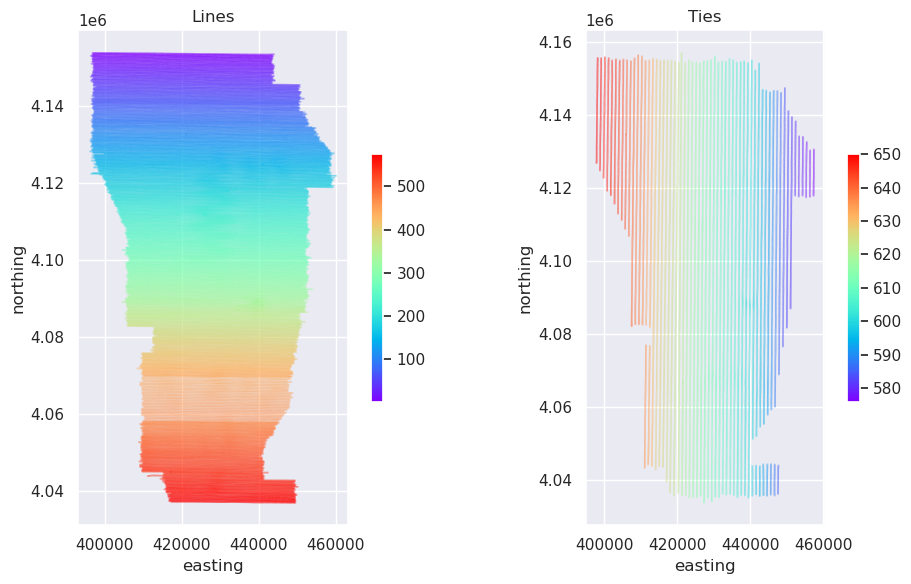

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

df = data_df[::10]
df = df[df.line_type == "line"]
ax = df.plot.scatter(
    "easting",
    "northing",
    c="line",
    s=0.02,
    cmap="rainbow",
    ax=axs[0],
    colorbar=False,
    title="Lines",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

df = data_df[::10]
df = df[df.line_type == "tie"]
ax = df.plot.scatter(
    "easting",
    "northing",
    c="line",
    s=0.02,
    cmap="rainbow",
    ax=axs[1],
    colorbar=False,
    title="Ties",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

# Cross-over levelling

## Find intersections

Potential intersections: 100%|██████████| 24122/24122 [08:41<00:00, 46.29it/s]
INFO:airbornegeo:found 24088 intersections


,line,tie,geometry,max_dist,easting,northing
0,1,598,POINT (442412 4153348),10.811184,442412.0,4153348.0
1,1,601,POINT (440387 4153346),5.637987,440387.0,4153346.0
2,1,602,POINT (439384 4153349),8.643726,439384.0,4153349.0
3,1,603,POINT (438323 4153354),9.194265,438323.0,4153354.0
4,1,604,POINT (437372 4153360),9.232622,437372.0,4153360.0
...,...,...,...,...,...,...
24083,575,618,POINT (422286 4037194),4.832029,422286.0,4037194.0
24084,575,619,POINT (421307 4037194),11.500039,421307.0,4037194.0
24085,575,622,POINT (420268 4037193),4.083969,420268.0,4037193.0
24086,575,623,POINT (419038 4037192),5.882457,419038.0,4037192.0


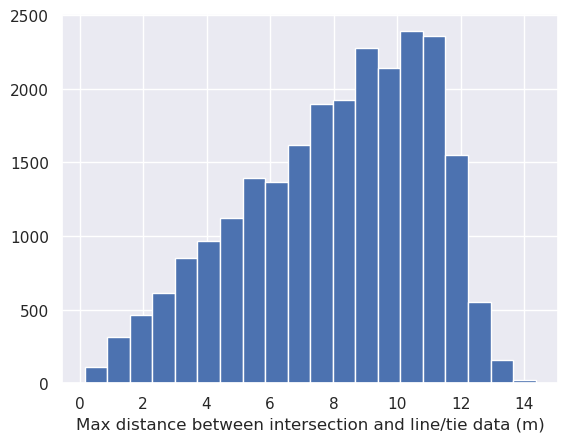

In [ ]:
# calculate theoretical intersection points
inters = airbornegeo.create_intersection_table(
    data_df,
    plot_map=False,
)
inters

## Add intersections as rows to the dataframe

In [15]:
data_df.head()

,line,line_type,lat84,lon84,easting,northing,unixtime,height,unlevelled_tfa,levelled_tfa,geometry,along_line_distance,distance_along_line
0,1,line,37.5256,-105.6335,443997.28,4153366.29,1.099466e+09,2488.22,-837.13,-841.75,POINT (443997.28 4153366.29),0.000000,0.000000
1,1,line,37.5256,-105.6338,443974.30,4153366.44,1.099466e+09,2488.37,-837.06,-841.68,POINT (443974.3 4153366.44),22.980490,22.980490
2,1,line,37.5256,-105.6341,443951.32,4153365.49,1.099466e+09,2488.51,-837.00,-841.62,POINT (443951.32 4153365.49),45.980118,45.980118
3,1,line,37.5256,-105.6343,443927.47,4153365.65,1.099466e+09,2488.66,-836.92,-841.54,POINT (443927.47 4153365.65),69.830654,69.830654
4,1,line,37.5256,-105.6346,443904.49,4153365.80,1.099466e+09,2488.80,-836.87,-841.49,POINT (443904.49 4153365.8),92.811144,92.811144


In [21]:
data_df, inters = airbornegeo.interpolate_intersections(
    data_df,
    inters,
    to_interp="unlevelled_tfa",
    window_width=500,
    method="cubic",
    extrapolate=False,
)

Intersections: 100%|██████████| 24088/24088 [06:22<00:00, 63.05it/s]


here


Segments:   0%|          | 0/649 [00:00<?, ?it/s]

1


Segments:   0%|          | 1/649 [00:00<01:40,  6.43it/s]

...

Segments: 100%|█████████▉| 647/649 [02:37<00:01,  1.76it/s]

649


Segments: 100%|█████████▉| 648/649 [02:38<00:00,  1.87it/s]

650


Segments: 100%|██████████| 649/649 [02:38<00:00,  4.09it/s]


In [22]:
# see which lines don't have intersections
airbornegeo.lines_without_intersections(data_df, inters)

[]

## Calculate initial cross-over errors

Intersections: 100%|██████████| 24088/24088 [02:01<00:00, 197.65it/s]


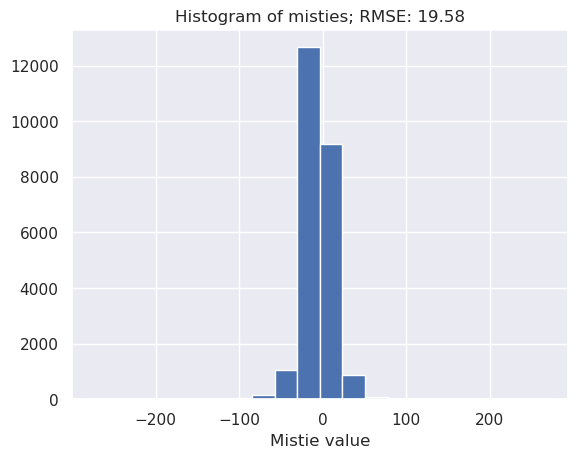

In [ ]:
inters = airbornegeo.calculate_crossover_errors(
    data_df,
    inters,
    data_col="unlevelled_tfa",
    plot_map=False,
)

In [26]:
inters.head()

,line,tie,geometry,max_dist,easting,northing,dist_along_flight_line,dist_along_flight_tie,flight_interpolation_type,tie_interpolation_type,mistie_0
0,1,598,POINT (442412 4153348),10.811184,442412.0,4153348.0,1585.815567,101406.261097,interpolated,interpolated,13.107907
1,1,601,POINT (440387 4153346),5.637987,440387.0,4153346.0,3611.147631,118349.152210,interpolated,interpolated,-2.060109
2,1,602,POINT (439384 4153349),8.643726,439384.0,4153349.0,4614.249436,117700.089264,interpolated,interpolated,-1.611797
3,1,603,POINT (438323 4153354),9.194265,438323.0,4153354.0,5675.316172,1553.779643,interpolated,interpolated,-9.936734
4,1,604,POINT (437372 4153360),9.232622,437372.0,4153360.0,6626.480517,118349.910213,interpolated,interpolated,-3.030689


## Level lines to ties

In [ ]:
data_df, inters_lines_to_ties = airbornegeo.crossover_levelling(
    data_df,
    inters,
    lines_to_level=data_df[data_df.line_type == "line"].line.unique(),
    data_col="unlevelled_tfa",
    levelled_col="mag_levelled_lines_to_ties_trend0",
    degree=0,
)
inters_lines_to_ties.head()

Intersections: 100%|██████████| 24088/24088 [02:02<00:00, 196.52it/s]


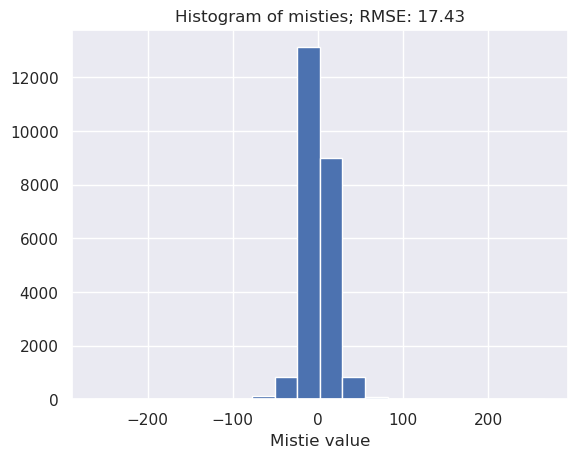

In [36]:
inters_lines_to_ties = airbornegeo.calculate_crossover_errors(
    data_df,
    inters_lines_to_ties,
    data_col="mag_levelled_lines_to_ties_trend0",
    plot_map=False,
)

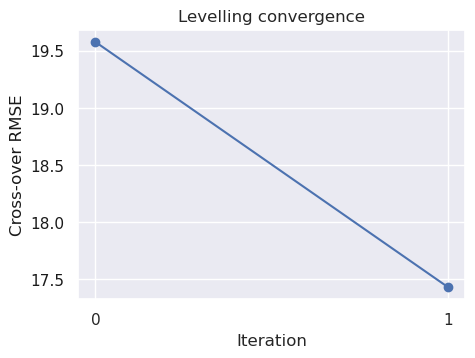

In [37]:
airbornegeo.plot_levelling_convergence(inters_lines_to_ties)

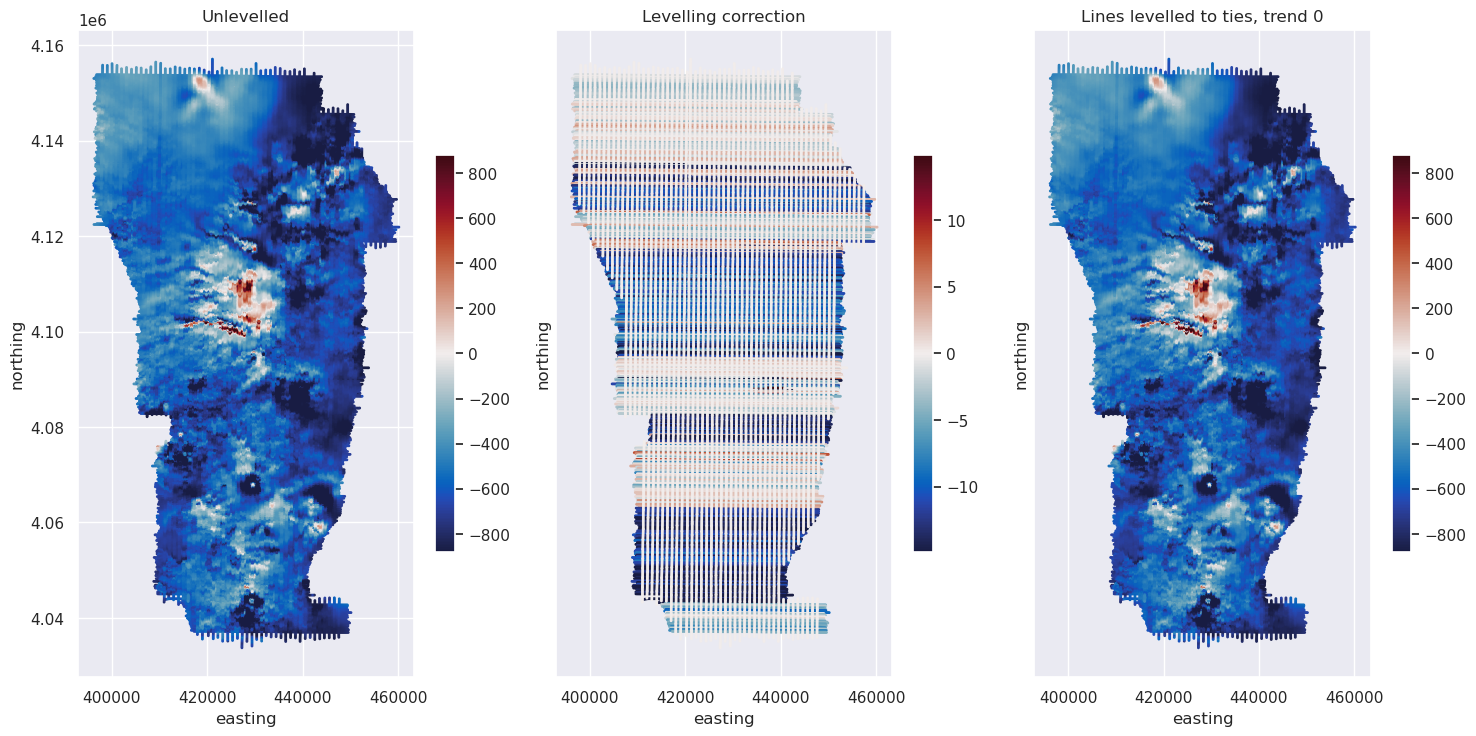

In [40]:
fig, axs = plt.subplots(1, 3, figsize=(15, 40))

data_df["levelling_correction"] = (
    data_df.unlevelled_tfa - data_df.mag_levelled_lines_to_ties_trend0
)

df = data_df[::10]

max_abs = vd.maxabs(data_df.unlevelled_tfa, percentile=95)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="unlevelled_tfa",
    s=1,
    ax=axs[0],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Unlevelled",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)


dif_maxabs = vd.maxabs(data_df.levelling_correction, percentile=95)

ax = df.plot.scatter(
    "easting",
    "northing",
    c="levelling_correction",
    s=1,
    ax=axs[1],
    cmap=cmocean.cm.balance,
    vmin=-dif_maxabs,
    vmax=dif_maxabs,
    colorbar=False,
    title="Levelling correction",
)
ax.set_yticks([])
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

ax = df.plot.scatter(
    "easting",
    "northing",
    c="mag_levelled_lines_to_ties_trend0",
    s=1,
    ax=axs[2],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Lines levelled to ties, trend 0",
)
ax.set_yticks([])
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

plt.tight_layout()
plt.show()

## Level ties to lines
We can also level the tie lines to the flight lines. We do this be supplying the `lines_to_level` parameter with the names of the tie lines. We will give this levelled data a new name `mag_levelled_ties_trend0`

In [41]:
# data_df, inters_ties_to_lines = airbornegeo.crossover_levelling(
#     data_df,
#     inters,
#     lines_to_level=data_df[data_df.tie == True].line.unique(),
#     data_col="unlevelled_tfa",
#     levelled_col="mag_levelled_ties_to_lines_trend0",
#     degree=0,
# )
# inters_ties_to_lines.head()

In [42]:
# inters_ties_to_lines = airbornegeo.calculate_crossover_errors(
#     data_df,
#     inters_ties_to_lines,
#     data_col="mag_levelled_ties_to_lines_trend0",
#     plot_map=True,
# )

In [43]:
# airbornegeo.plot_levelling_convergence(inters_ties_to_lines)

In [44]:
# fig, axs = plt.subplots(1, 3, figsize=(15, 40))

# max_abs = vd.maxabs(data_df.mag, percentile=95)
# ax = data_df[::10].plot.scatter(
#     "easting",
#     "northing",
#     c="mag",
#     s=1,
#     ax=axs[0],
#     cmap=cmocean.cm.balance,
#     vmin=-max_abs,
#     vmax=max_abs,
#     colorbar=False,
#     title="Unlevelled",
# )
# ax.set_aspect("equal")
# plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

# data_df["levelling_correction"] = (
#     data_df.mag - data_df.mag_levelled_ties_to_lines_trend0
# )
# ax = data_df[::10].plot.scatter(
#     "easting",
#     "northing",
#     c="levelling_correction",
#     s=1,
#     ax=axs[1],
#     cmap=cmocean.cm.balance,
#     vmin=-max_abs,
#     vmax=max_abs,
#     colorbar=False,
#     title="Levelling correction",
# )
# ax.set_yticks([])
# ax.set_aspect("equal")
# plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

# ax = data_df[::10].plot.scatter(
#     "easting",
#     "northing",
#     c="mag_levelled_ties_to_lines_trend0",
#     s=1,
#     ax=axs[2],
#     cmap=cmocean.cm.balance,
#     vmin=-max_abs,
#     vmax=max_abs,
#     colorbar=False,
#     title="Ties levelled to lines, trend 0",
# )
# ax.set_yticks([])
# ax.set_aspect("equal")
# plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

# plt.tight_layout()
# plt.show()

We can repeat these steps, increasing the trend order if we need more levelling, and alternating between levelling lines or ties. In some case, we want to iteratively repeat the levelling. This is shown below.

In [45]:
data_df, inters_alternating_iterative = (
    airbornegeo.alternating_iterative_line_levelling(
        data_df,
        inters,
        data_col="unlevelled_tfa",
        levelled_col="mag_levelled_alternating_trend1",
        degree=1,
        iterations=5,
    )
)
inters_alternating_iterative.head()

Iteration:  40%|████      | 2/5 [21:59<32:59, 659.95s/it]


KeyboardInterrupt: 

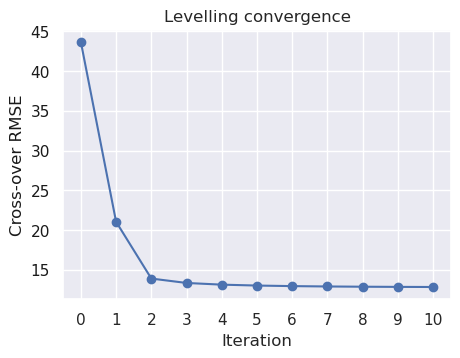

In [ ]:
airbornegeo.plot_levelling_convergence(inters_alternating_iterative)

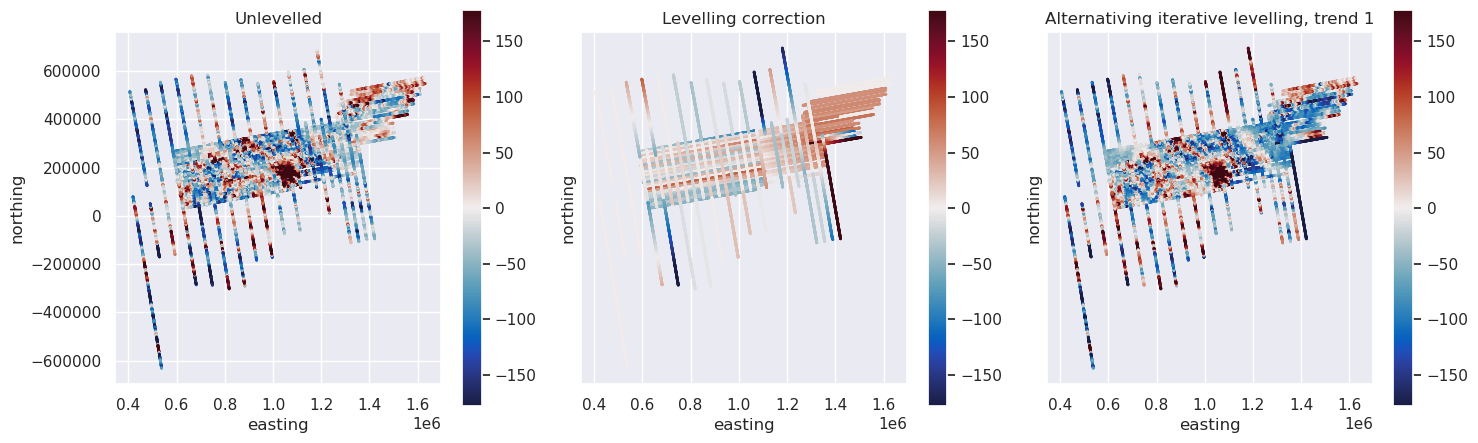

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 40))

max_abs = vd.maxabs(data_df.mag, percentile=95)
ax = data_df[::10].plot.scatter(
    "easting",
    "northing",
    c="mag",
    s=1,
    ax=axs[0],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Unlevelled",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

data_df["levelling_correction"] = data_df.mag - data_df.mag_levelled_alternating_trend1
ax = data_df[::10].plot.scatter(
    "easting",
    "northing",
    c="levelling_correction",
    s=1,
    ax=axs[1],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Levelling correction",
)
ax.set_yticks([])
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

ax = data_df[::10].plot.scatter(
    "easting",
    "northing",
    c="mag_levelled_alternating_trend1",
    s=1,
    ax=axs[2],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Alternativing iterative levelling, trend 1",
)
ax.set_yticks([])
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

plt.tight_layout()
plt.show()

# Equivalent Source levelling

In [ ]:
data_df["mag_levelled"] = airbornegeo.equivalent_source_levelling(
    data_df,
    "mag_unlevelled",
    degree=2,
    max_dist=20e3,
    damping=None,
    depth="default",
    block_size=20e3,
    max_iterations=5,
)
data_df.head()